# Environment Setup

In [1]:

import sklearn
import numpy as np
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("All good! ✅")

numpy: 2.3.5
sklearn: 1.7.2
All good! ✅


# Boston Housing Dataset

In [2]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt

data = fetch_california_housing()

X = data.data[:, 2]   
Y = data.target        

print("Total examples:", len(X))
print("X (first 5):", X[:5])
print("Y (first 5):", Y[:5])

Total examples: 20640
X (first 5): [6.98412698 6.23813708 8.28813559 5.8173516  6.28185328]
Y (first 5): [4.526 3.585 3.521 3.413 3.422]


# Data Visualize karo

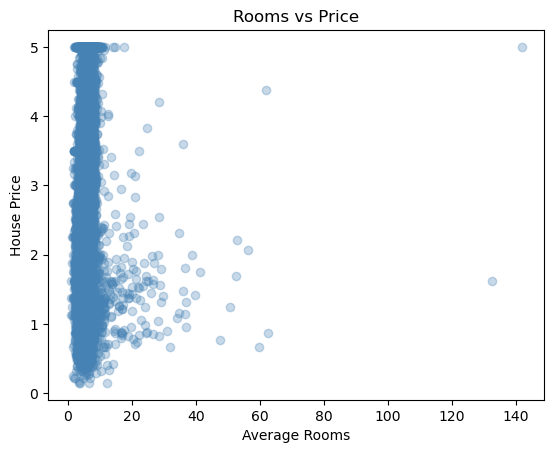

In [3]:
plt.scatter(X, Y, alpha=0.3, color='steelblue')
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Rooms vs Price")
plt.show()

# Data Clean

Pehle kitne the: 20640
Ab kitne hain: 19958


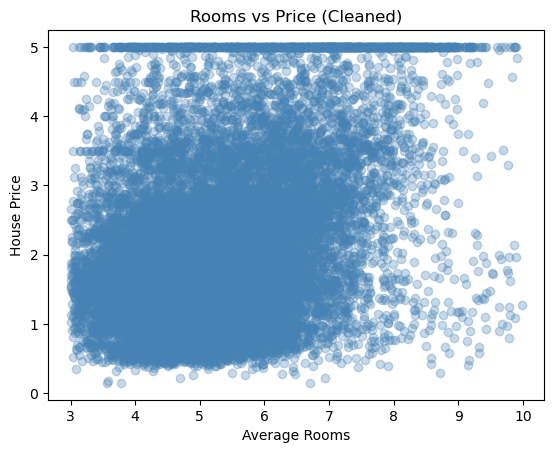

In [4]:

mask = (X > 3) & (X < 10)
X_clean = X[mask]
Y_clean = Y[mask]

print("Pehle kitne the:", len(X))
print("Ab kitne hain:", len(X_clean))

# Plot again
plt.scatter(X_clean, Y_clean, alpha=0.3, color='steelblue')
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Rooms vs Price (Cleaned)")
plt.show()

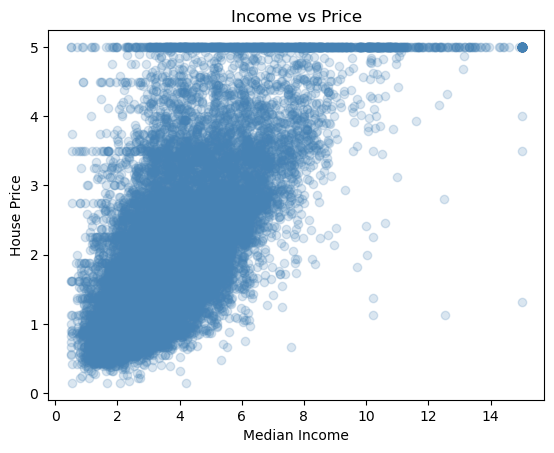

In [5]:

X_clean = data.data[:, 0]  
Y_clean = data.target      

plt.scatter(X_clean, Y_clean, alpha=0.2, color='steelblue')
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs Price")
plt.show()

In [6]:

X_norm = (X_clean - X_clean.mean()) / X_clean.std()
Y_norm = (Y_clean - Y_clean.mean()) / Y_clean.std()


def compute_mse(m, b, X, Y):
    n = len(X)
    total_error = 0
    for i in range(n):
        predicted = m * X[i] + b      
        error = Y[i] - predicted       
        total_error += error ** 2      
    return total_error / n             


m = 0.0  
b = 0.0  

loss = compute_mse(m, b, X_norm, Y_norm)
print(f"Initial MSE Loss: {loss:.4f}")

Initial MSE Loss: 1.0000


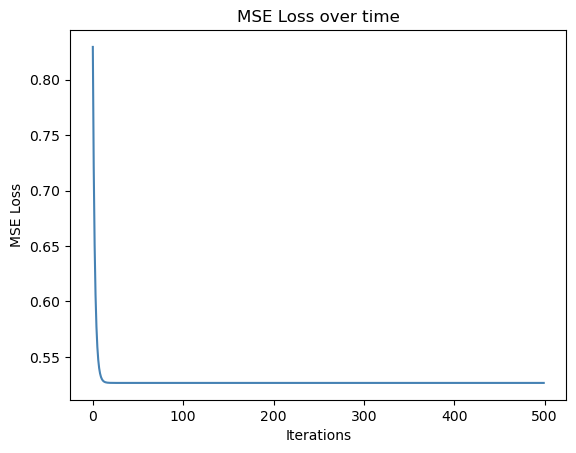

Final MSE Loss: 0.5266
Final m: 0.6881, b: -0.0000


In [7]:
def update_weights_MSE(m, b, X, Y, learning_rate):
    m_deriv = 0
    b_deriv = 0
    n = len(X)
    
    for i in range(n):
        predicted = m * X[i] + b
        error = Y[i] - predicted
        
        
        m_deriv += -2 * X[i] * error
        b_deriv += -2 * error
    
    
    m = m - (m_deriv / n) * learning_rate
    b = b - (b_deriv / n) * learning_rate
    
    return m, b


m, b = 0.0, 0.0
learning_rate = 0.1
loss_history = []

for i in range(500):
    m, b = update_weights_MSE(m, b, X_norm, Y_norm, learning_rate)
    loss = compute_mse(m, b, X_norm, Y_norm)
    loss_history.append(loss)


plt.plot(loss_history, color='steelblue')
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("MSE Loss over time")
plt.show()

print(f"Final MSE Loss: {loss_history[-1]:.4f}")
print(f"Final m: {m:.4f}, b: {b:.4f}")

In [9]:

m, b = 0.0, 0.0
learning_rate = 0.01  
loss_history_slow = []

for i in range(500):
    m, b = update_weights_MSE(m, b, X_norm, Y_norm, learning_rate)
    loss = compute_mse(m, b, X_norm, Y_norm)
    loss_history_slow.append(loss)

print(f"Final MSE Loss (lr=0.01): {loss_history_slow[-1]:.4f}")

Final MSE Loss (lr=0.01): 0.5266


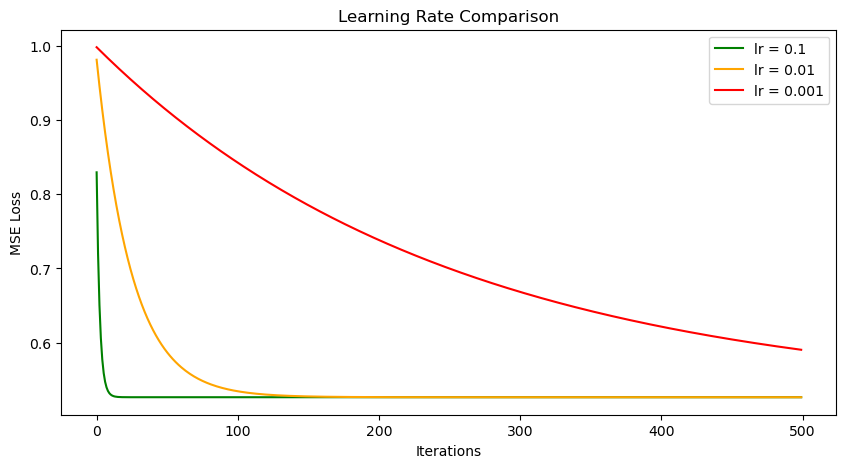

lr=0.1  → Final Loss: 0.5266
lr=0.01 → Final Loss: 0.5266
lr=0.001→ Final Loss: 0.5905


In [10]:

m, b = 0.0, 0.0
loss_history_veryshow = []

for i in range(500):
    m, b = update_weights_MSE(m, b, X_norm, Y_norm, 0.001)
    loss = compute_mse(m, b, X_norm, Y_norm)
    loss_history_veryshow.append(loss)


plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='lr = 0.1', color='green')
plt.plot(loss_history_slow, label='lr = 0.01', color='orange')
plt.plot(loss_history_veryshow, label='lr = 0.001', color='red')
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

print(f"lr=0.1  → Final Loss: {loss_history[-1]:.4f}")
print(f"lr=0.01 → Final Loss: {loss_history_slow[-1]:.4f}")
print(f"lr=0.001→ Final Loss: {loss_history_veryshow[-1]:.4f}")

# MAE 

In [11]:
def update_weights_MAE(m, b, X, Y, learning_rate):
    m_deriv = 0
    b_deriv = 0
    N = len(X)
    for i in range(N):
        
        if Y[i] - (m * X[i] + b) > 0:
            m_deriv += -X[i]
            b_deriv += -1
        else:
            m_deriv += X[i]
            b_deriv += 1

    m -= (m_deriv / float(N)) * learning_rate
    b -= (b_deriv / float(N)) * learning_rate
    return m, b


m, b = 0.0, 0.0
for i in range(500):
    m, b = update_weights_MAE(m, b, X_norm, Y_norm, 0.01)

print(f"Final m: {m:.4f}, b: {b:.4f}")

Final m: 0.7204, b: -0.1441


# Huber Loss!

In [12]:
def update_weights_Huber(m, b, X, Y, learning_rate, delta=1.0):
    m_deriv = 0
    b_deriv = 0
    N = len(X)
    for i in range(N):
        error = Y[i] - (m * X[i] + b)
        if abs(error) <= delta:
            # Chhoti error — MSE ki tarah
            m_deriv += -X[i] * error
            b_deriv += -error
        else:
            # Badi error — MAE ki tarah
            m_deriv += -X[i] * delta * np.sign(error)
            b_deriv += -delta * np.sign(error)

    m -= (m_deriv / float(N)) * learning_rate
    b -= (b_deriv / float(N)) * learning_rate
    return m, b


m, b = 0.0, 0.0
for i in range(500):
    m, b = update_weights_Huber(m, b, X_norm, Y_norm, 0.01)

print(f"Final m: {m:.4f}, b: {b:.4f}")

Final m: 0.6914, b: -0.0626


# Breast Cancer

In [13]:
from sklearn.datasets import load_breast_cancer

data_bc = load_breast_cancer()


X_bc = data_bc.data[:, [0, 3]]  
Y_bc = data_bc.target            

print("Total examples:", len(X_bc))
print("Classes:", data_bc.target_names)
print("X shape:", X_bc.shape)

Total examples: 569
Classes: ['malignant' 'benign']
X shape: (569, 2)


# Binary Cross Entropy

In [14]:

X_bc = (X_bc - X_bc.mean(axis=0)) / X_bc.std(axis=0)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_bce(W, b, X, Y):
    n = len(X)
    total_loss = 0
    for i in range(n):
        z = np.dot(X[i], W) + b
        pred = sigmoid(z)
        # Log loss formula
        loss = -Y[i] * np.log(pred) - (1 - Y[i]) * np.log(1 - pred)
        total_loss += loss
    return total_loss / n

W = np.zeros(2)
b = 0.0

loss = compute_bce(W, b, X_bc, Y_bc)
print(f"Initial BCE Loss: {loss:.4f}")

Initial BCE Loss: 0.6931


# BCE ka gradient descent 

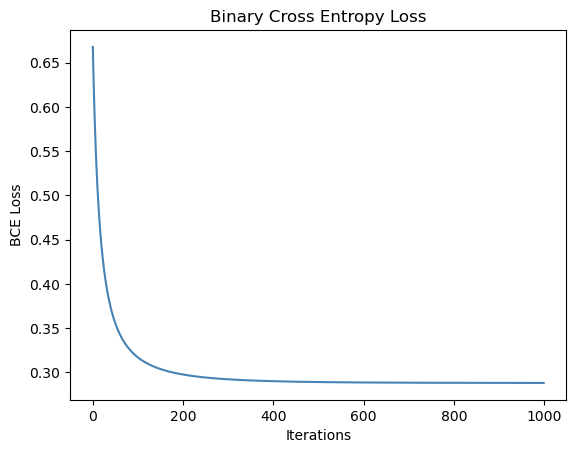

Final BCE Loss: 0.2879


In [16]:
def update_weights_BCE(W, b, X, Y, learning_rate):
    W_deriv = np.zeros(2)
    b_deriv = 0
    N = len(X)
    
    for i in range(N):
        z = np.dot(X[i], W) + b
        pred = sigmoid(z)
        error = pred - Y[i]
        
        # Gradients
        W_deriv += X[i] * error
        b_deriv += error
    
    # Update
    W -= (W_deriv / N) * learning_rate
    b -= (b_deriv / N) * learning_rate
    
    return W, b

# Training
W = np.zeros(2)
b = 0.0
loss_history_bce = []

for i in range(1000):
    W, b = update_weights_BCE(W, b, X_bc, Y_bc, 0.1)
    loss = compute_bce(W, b, X_bc, Y_bc)
    loss_history_bce.append(loss)

# Plot
plt.plot(loss_history_bce, color='steelblue')
plt.xlabel("Iterations")
plt.ylabel("BCE Loss")
plt.title("Binary Cross Entropy Loss")
plt.show()

print(f"Final BCE Loss: {loss_history_bce[-1]:.4f}")

# Hinge Loss

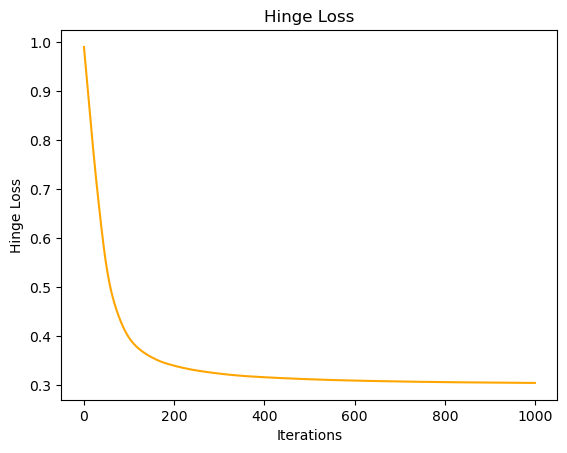

Final Hinge Loss: 0.3042


In [17]:
# Pehle labels change karo — SVM ko -1 aur +1 chahiye!
Y_hinge = np.where(Y_bc == 0, -1, 1)

def compute_hinge(W, b, X, Y):
    n = len(X)
    total_loss = 0
    for i in range(n):
        z = np.dot(X[i], W) + b
        # max(0, 1 - y*z)
        loss = max(0, 1 - Y[i] * z)
        total_loss += loss
    return total_loss / n

def update_weights_Hinge(W, b, X, Y, learning_rate):
    W_deriv = np.zeros(2)
    b_deriv = 0
    N = len(X)
    for i in range(N):
        z = np.dot(X[i], W) + b
        if Y[i] * z < 1:
            W_deriv += -X[i] * Y[i]
            b_deriv += -Y[i]
    W -= (W_deriv / N) * learning_rate
    b -= (b_deriv / N) * learning_rate
    return W, b

# Training
W = np.zeros(2)
b = 0.0
loss_history_hinge = []

for i in range(1000):
    W, b = update_weights_Hinge(W, b, X_bc, Y_hinge, 0.01)
    loss = compute_hinge(W, b, X_bc, Y_hinge)
    loss_history_hinge.append(loss)

plt.plot(loss_history_hinge, color='orange')
plt.xlabel("Iterations")
plt.ylabel("Hinge Loss")
plt.title("Hinge Loss")
plt.show()

print(f"Final Hinge Loss: {loss_history_hinge[-1]:.4f}")

 # Iris Dataset

In [18]:
from sklearn.datasets import load_iris
import tensorflow as tf
from tensorflow import keras

data_iris = load_iris()
X_iris = data_iris.data[:, [0, 3]]  # 2 features
Y_iris = data_iris.target            # 3 classes

X_iris = (X_iris - X_iris.mean(axis=0)) / X_iris.std(axis=0)

Y_iris_oh = keras.utils.to_categorical(Y_iris, 3)

print("X shape:", X_iris.shape)
print("Y shape:", Y_iris_oh.shape)
print("Classes:", data_iris.target_names)

X shape: (150, 2)
Y shape: (150, 3)
Classes: ['setosa' 'versicolor' 'virginica']


E:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


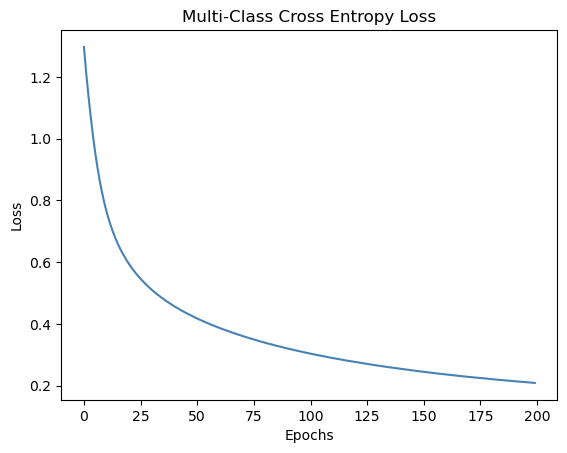

Final Loss: 0.2085
Final Accuracy: 0.9533


In [19]:
# Multi-Class Cross Entropy Model
model_mce = keras.Sequential([
    keras.layers.Dense(3, activation='softmax', input_shape=(2,))
])

model_mce.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_mce = model_mce.fit(
    X_iris, Y_iris_oh,
    epochs=200,
    verbose=0
)

# Plot
plt.plot(history_mce.history['loss'], color='steelblue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Multi-Class Cross Entropy Loss")
plt.show()

print(f"Final Loss: {history_mce.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {history_mce.history['accuracy'][-1]:.4f}")

# KL Divergence

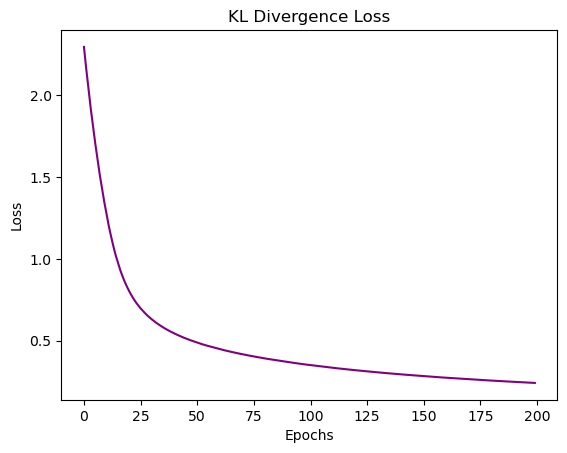

Final Loss: 0.2418
Final Accuracy: 0.9533


In [21]:
model_kl = keras.Sequential([
    keras.layers.Dense(3, activation='softmax', input_shape=(2,))
])

model_kl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=keras.losses.KLDivergence(),  # String ki jagah direct class use karo!
    metrics=['accuracy']
)

history_kl = model_kl.fit(
    X_iris, Y_iris_oh,
    epochs=200,
    verbose=0
)

plt.plot(history_kl.history['loss'], color='purple')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("KL Divergence Loss")
plt.show()

print(f"Final Loss: {history_kl.history['loss'][-1]:.4f}")
print(f"Final Accuracy: {history_kl.history['accuracy'][-1]:.4f}")